# What Drives Views on Branded Short-Form Content?
### An analysis of 54 of my sponsored brand videos (Oct 2024 – Sep 2026)

**Questions**
1. Do videos that open with humor get more views than videos that open directly with the promotion?
2. Is there a trade-off between **reach** (views) and **brand exposure** (whether viewers stay until the brand appears)?
3. Do longer videos perform worse, and how unusual is my 2:38 inDrive video?
4. Does *when* the promotion starts matter?

**How to run:** upload your CSV with the folder icon on the left, then click the first grey box and press **Shift + Enter** repeatedly until the end.

In [ ]:
# 1. Setup (run this first)
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 50)
os.makedirs("figures", exist_ok=True)
print("Setup complete.")

Setup complete.


## 2. Load and clean the data
This box finds your CSV automatically (any name works), renames the columns to short names, and checks for problems.

In [ ]:
csv_files = [f for f in glob.glob("*.csv")]
if not csv_files:
    raise FileNotFoundError("No CSV found. Click the folder icon on the left and upload your data file.")
DATA_PATH = "video_data.csv" if "video_data.csv" in csv_files else csv_files[0]
print("Using file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

# Match columns by keywords, so small differences in your headings don't matter
def find(*keys):
    for c in df.columns:
        name = c.lower()
        if all(k in name for k in keys):
            return c
    raise ValueError(f"Could not find a column containing {keys}. Your columns are: {list(df.columns)}")

df = df.rename(columns={
    find("video", "id"): "video_id",
    find("brand"): "brand",
    find("date"): "post_date",
    find("views"): "views",
    find("length"): "length_sec",
    find("promo"): "promo_start_sec",
    find("opening"): "opening_style",
    find("watch"): "avg_watch_time_sec",
    find("notes"): "notes",
})

for c in ["views", "length_sec", "promo_start_sec", "avg_watch_time_sec"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")
df["brand"] = df["brand"].astype(str).str.strip()
df["opening_style"] = df["opening_style"].astype(str).str.strip().str.lower()
df["notes"] = df["notes"].astype(str).str.lower()

problems = df[df[["views", "length_sec", "promo_start_sec", "post_date"]].isna().any(axis=1)]
if len(problems):
    print("Fix these rows in your spreadsheet:")
    display(problems)
else:
    print(f"Loaded {len(df)} videos with no problems.")
print("Opening styles:", df["opening_style"].value_counts().to_dict())

Using file: Video_data - Sheet1.csv
Loaded 54 videos with no problems.
Opening styles: {'humor': 45, 'direct': 6, 'normal voiceover': 2, 'emotional': 1}


## 3. Create analysis variables
- **style_group**: humor, direct, or other (emotional and normal voiceover are grouped as "other" because there are too few to analyse separately).
- **log_views**: views on a log scale, because a few viral videos are far bigger than the rest.
- **promo_share**: when the promotion starts as a share of the video (0.5 = halfway).
- **completion_rate**: average watch time ÷ video length.
- **reached_promo**: did the *average* viewer stay until the brand appeared?
- **paid_ads**: the brand also ran ads (only organic views were recorded).
- **post_order**: 1 = oldest video, to account for my account growing over time.

In [ ]:
df = df.dropna(subset=["views", "length_sec", "promo_start_sec", "post_date"]).copy()
df = df.sort_values("post_date").reset_index(drop=True)

df["style_group"] = np.where(df["opening_style"].isin(["humor", "direct"]), df["opening_style"], "other")
df["log_views"] = np.log10(df["views"])
df["length_min"] = df["length_sec"] / 60
df["over_60s"] = np.where(df["length_sec"] > 60, "Over 60s", "60s or less")
df["promo_share"] = (df["promo_start_sec"] / df["length_sec"]).clip(0, 1)
df["completion_rate"] = df["avg_watch_time_sec"] / df["length_sec"]
df["reached_promo"] = df["avg_watch_time_sec"] >= df["promo_start_sec"]
df["paid_ads"] = df["notes"].str.contains("paid").astype(int)
df["direct_open"] = (df["style_group"] == "direct").astype(int)
df["post_order"] = np.arange(1, len(df) + 1)

df[["brand", "views", "length_sec", "promo_start_sec", "avg_watch_time_sec", "style_group", "reached_promo"]].head(10)

,brand,views,length_sec,promo_start_sec,avg_watch_time_sec,style_group,reached_promo
0,Ultima-Prime 1.0 promotion,368100,54,31,13.2,humor,False
1,Nepal Life Insurance-Dashain campaign,41400,51,32,11.5,humor,False
2,Bajaj Nepal,81600,57,26,12.1,humor,False
3,Honor Nepal,30468,58,32,6.4,humor,False
4,Matka Takeaway,18133,41,13,6.9,humor,False
5,Shivashakti edumart,230300,63,16,7.7,humor,False
6,Jeevee-New Year,60600,57,34,10.1,humor,False
7,Karobar App,38203,61,34,9.0,humor,False
8,Ultima- Baneshwor Opening campaign,179600,59,20,11.3,humor,False
9,ISAS Beauty Academy,23817,62,17,5.8,humor,False


## 4. Overall picture

Videos: 54  |  Period: Oct 2024 to Sep 2026
Median views: 55,222   Mean views: 134,424
(The mean is much higher than the median because a few viral videos pull it up.)

Top 5 videos:


,brand,views,length_sec,style_group
14,WaiWai,1469575,46,humor
49,inDrive-Dream it do it,859000,158,other
19,Fonepoints,557100,79,humor
0,Ultima-Prime 1.0 promotion,368100,54,humor
23,Gazzabko Noodles,358600,52,humor


Bottom 5 videos:


,brand,views,length_sec,style_group
50,The Body Shop Nepal,8046,68,direct
21,Himalaya Happy Pet,8787,38,other
22,Ponds,15507,40,other
12,Ncell,17648,59,humor
4,Matka Takeaway,18133,41,humor


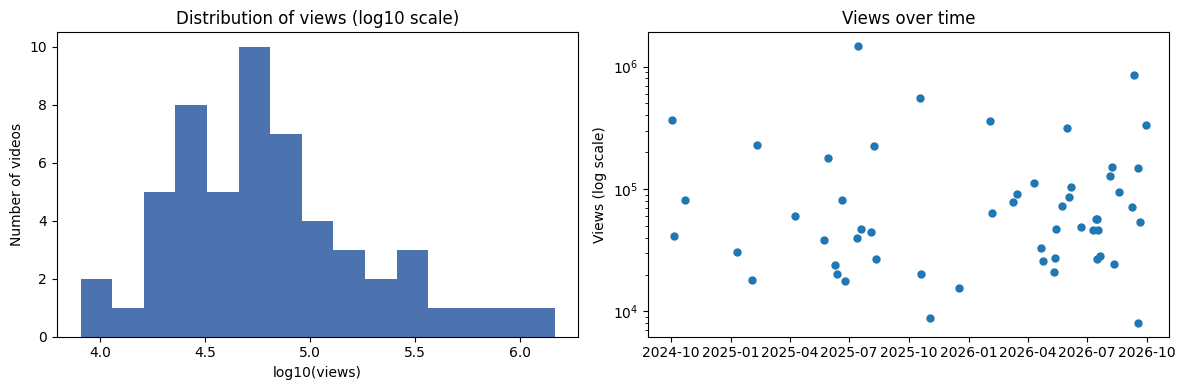

In [ ]:
print(f"Videos: {len(df)}  |  Period: {df['post_date'].min():%b %Y} to {df['post_date'].max():%b %Y}")
print(f"Median views: {df['views'].median():,.0f}   Mean views: {df['views'].mean():,.0f}")
print("(The mean is much higher than the median because a few viral videos pull it up.)")

print("\nTop 5 videos:")
display(df.nlargest(5, "views")[["brand", "views", "length_sec", "style_group"]])
print("Bottom 5 videos:")
display(df.nsmallest(5, "views")[["brand", "views", "length_sec", "style_group"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["log_views"], bins=15, color="#4C72B0")
axes[0].set(title="Distribution of views (log10 scale)", xlabel="log10(views)", ylabel="Number of videos")
axes[1].scatter(df["post_date"], df["views"], s=25)
axes[1].set_yscale("log"); axes[1].set(title="Views over time", ylabel="Views (log scale)")
plt.tight_layout(); plt.savefig("figures/01_overview.png", dpi=150); plt.show()

## 5. Opening style: humor vs. direct promotion
We compare **medians** and use the Mann-Whitney U test (works for small, skewed samples).

⚠️ Only a few videos are "direct", and several are for the same brand (Honda). So the brand itself could explain part of any difference. Treat the result as a strong pattern, not proof.

,videos,median_views,mean_views
style_group,,,
direct,6,22208.0,20923.0
humor,45,64100.0,138890.0
other,3,15507.0,294431.0


Humor vs direct: Mann-Whitney U = 252, p = 0.0001
Humor median is 2.9x the direct median.

Direct videos: inDrive-Rides for goals, inDrive-Brand ambassador campaign, Honda-showroom 1, Honda-showroom 2, Honda- NAIMA Expo, The Body Shop Nepal


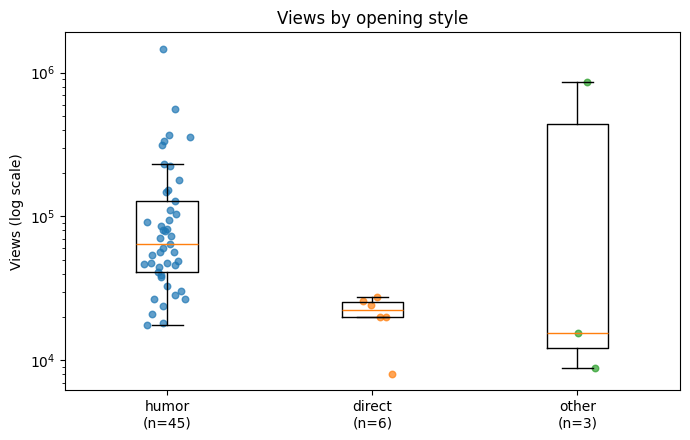

In [ ]:
summary = df.groupby("style_group")["views"].agg(videos="count", median_views="median", mean_views="mean").round(0)
display(summary)

humor = df.loc[df["style_group"] == "humor", "views"]
direct = df.loc[df["style_group"] == "direct", "views"]
u, p = stats.mannwhitneyu(humor, direct, alternative="two-sided")
print(f"Humor vs direct: Mann-Whitney U = {u:.0f}, p = {p:.4f}")
print(f"Humor median is {humor.median() / direct.median():.1f}x the direct median.")
print("\nDirect videos:", ", ".join(df.loc[df['style_group'] == 'direct', 'brand']))

order = ["humor", "direct", "other"]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([df.loc[df["style_group"] == g, "views"] for g in order], showfliers=False)
for i, g in enumerate(order, 1):
    y = df.loc[df["style_group"] == g, "views"]
    ax.scatter(np.random.normal(i, 0.05, len(y)), y, alpha=0.7, s=22)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels([f"{g}\n(n={(df['style_group'] == g).sum()})" for g in order])
ax.set_yscale("log"); ax.set(title="Views by opening style", ylabel="Views (log scale)")
plt.tight_layout(); plt.savefig("figures/02_opening_style.png", dpi=150); plt.show()

## 6. Reach vs. brand exposure
Views are only half the story for a brand. If most viewers leave before the brand appears, a high view count may deliver less brand exposure than it seems.

Here we check whether the **average viewer was still watching when the promotion started**. Points **above** the dashed line = the average viewer reached the promotion.

,videos,median_views,median_watch_sec,median_promo_start_sec,pct_avg_viewer_reached_promo
style_group,,,,,
direct,6,22208.5,8.5,3.5,100.0
humor,45,64100.0,11.5,27.0,2.2
other,3,15507.0,8.0,27.0,0.0


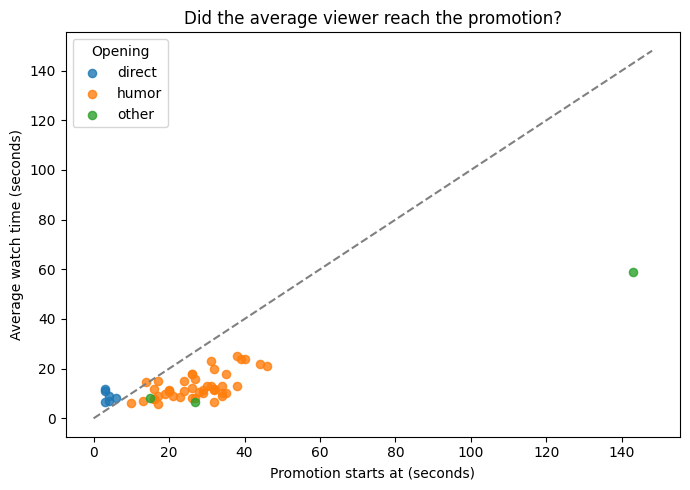

In [ ]:
exposure = df.groupby("style_group").agg(
    videos=("views", "count"),
    median_views=("views", "median"),
    median_watch_sec=("avg_watch_time_sec", "median"),
    median_promo_start_sec=("promo_start_sec", "median"),
    pct_avg_viewer_reached_promo=("reached_promo", lambda s: round(100 * s.mean(), 1)),
)
display(exposure)

fig, ax = plt.subplots(figsize=(7, 5))
for g, sub in df.groupby("style_group"):
    ax.scatter(sub["promo_start_sec"], sub["avg_watch_time_sec"], label=g, s=35, alpha=0.8)
lim = max(df["promo_start_sec"].max(), df["avg_watch_time_sec"].max()) + 5
ax.plot([0, lim], [0, lim], "--", color="grey")
ax.set(xlabel="Promotion starts at (seconds)", ylabel="Average watch time (seconds)",
       title="Did the average viewer reach the promotion?")
ax.legend(title="Opening")
plt.tight_layout(); plt.savefig("figures/03_reach_vs_exposure.png", dpi=150); plt.show()

## 7. Video length: the "long video paradox"

,videos,median_views
over_60s,,
60s or less,38,48258.0
Over 60s,16,71970.0


Length vs views: Spearman rho = 0.30, p = 0.030
Length vs completion rate: Spearman rho = -0.15, p = 0.265

Longest video: inDrive-Dream it do it (158s), 859,000 views, more than 96% of all videos. Opening style: emotional.


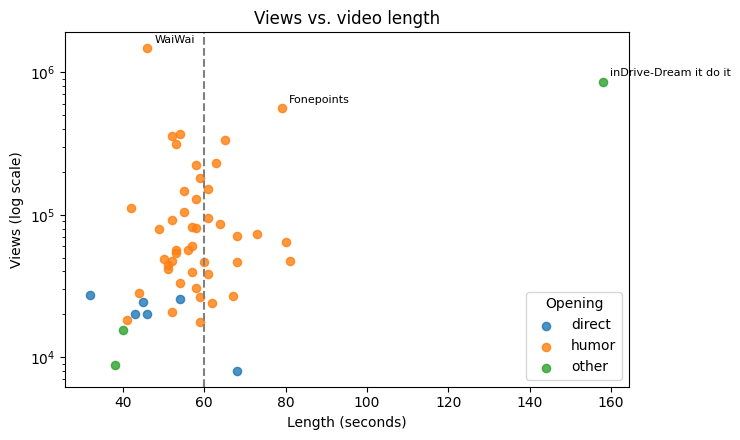

In [ ]:
display(df.groupby("over_60s")["views"].agg(videos="count", median_views="median").round(0))
rho, p = stats.spearmanr(df["length_sec"], df["views"])
print(f"Length vs views: Spearman rho = {rho:.2f}, p = {p:.3f}")
rho2, p2 = stats.spearmanr(df["length_sec"], df["completion_rate"], nan_policy="omit")
print(f"Length vs completion rate: Spearman rho = {rho2:.2f}, p = {p2:.3f}")

longest = df.loc[df["length_sec"].idxmax()]
pct_rank = (df["views"] < longest["views"]).mean() * 100
print(f"\nLongest video: {longest['brand']} ({longest['length_sec']:.0f}s), {longest['views']:,.0f} views, "
      f"more than {pct_rank:.0f}% of all videos. Opening style: {longest['opening_style']}.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for g, sub in df.groupby("style_group"):
    ax.scatter(sub["length_sec"], sub["views"], label=g, s=35, alpha=0.8)
ax.axvline(60, ls="--", c="grey")
for _, r in df.nlargest(3, "views").iterrows():
    ax.annotate(r["brand"], (r["length_sec"], r["views"]), fontsize=8, xytext=(5, 4), textcoords="offset points")
ax.set_yscale("log"); ax.set(title="Views vs. video length", xlabel="Length (seconds)", ylabel="Views (log scale)")
ax.legend(title="Opening")
plt.tight_layout(); plt.savefig("figures/04_length_vs_views.png", dpi=150); plt.show()

## 8. When does the promotion start?

Humor videos only: promo position vs views, Spearman rho = 0.25, p = 0.102
(Restricted to humor videos so the result isn't just the humor-vs-direct difference again.)


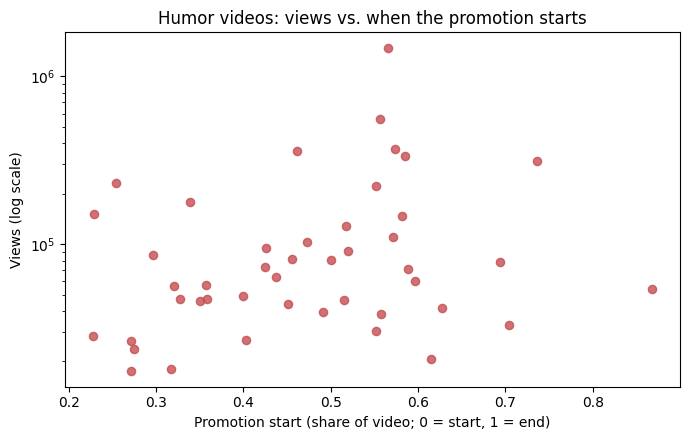

In [ ]:
hd = df[df["style_group"] == "humor"]
rho, p = stats.spearmanr(hd["promo_share"], hd["views"])
print(f"Humor videos only: promo position vs views, Spearman rho = {rho:.2f}, p = {p:.3f}")
print("(Restricted to humor videos so the result isn't just the humor-vs-direct difference again.)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(hd["promo_share"], hd["views"], s=35, alpha=0.8, c="#C44E52")
ax.set_yscale("log")
ax.set(title="Humor videos: views vs. when the promotion starts",
       xlabel="Promotion start (share of video; 0 = start, 1 = end)", ylabel="Views (log scale)")
plt.tight_layout(); plt.savefig("figures/05_promo_timing.png", dpi=150); plt.show()

## 9. Putting it together: regression
Estimates each factor's effect **while holding the others constant**. Uses humor and direct videos only.

`log10(views) ~ length (min) + promo position + direct opening + paid ads + post order`

**Reading the table:** "% change in views" is the estimated effect of a one-unit increase (for example, one extra minute of length, or a direct opening instead of humor), holding everything else constant.

⚠️ Look at the direction and the confidence interval, not just the p-value. Wide intervals mean "uncertain".

**Why the intervals may be wide:** in my data, direct videos are also the videos where the promotion starts earliest, so the model struggles to separate "direct opening" from "early promotion". The simpler comparisons in Sections 5 and 6 are clearer for this question.

In [ ]:
reg = df[df["style_group"].isin(["humor", "direct"])].copy()
formula = "log_views ~ length_min + promo_share + direct_open + paid_ads + post_order"
model = smf.ols(formula, data=reg).fit(cov_type="HC3")
print(f"n = {len(reg)}")
print(model.summary())

def effects_table(m):
    ci = m.conf_int()
    return pd.DataFrame({
        "% change in views": (10 ** m.params - 1) * 100,
        "95% CI low (%)": (10 ** ci[0] - 1) * 100,
        "95% CI high (%)": (10 ** ci[1] - 1) * 100,
        "p-value": m.pvalues,
    }).drop("Intercept").round(1)

display(effects_table(model))

n = 51
                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     5.652
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           0.000398
Time:                        16:28:06   Log-Likelihood:                -23.323
No. Observations:                  51   AIC:                             58.65
Df Residuals:                      45   BIC:                             70.24
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       4.4440      0.545      8.15

,% change in views,95% CI low (%),95% CI high (%),p-value
length_min,24.4,-84.2,879.9,0.8
promo_share,474.4,-35.0,4975.3,0.1
direct_open,-46.7,-81.9,57.0,0.3
paid_ads,33.3,-44.5,220.3,0.5
post_order,-0.1,-1.9,1.6,0.9


## 10. Robustness checks
Do the conclusions hold if we remove (a) the most-viewed video or (b) videos where brands also ran paid ads? (The 2:38 inDrive video is already excluded from the regression because its opening style is "emotional".)

In [ ]:
checks = {
    "All videos": reg,
    "Without top video": reg.drop(index=reg["views"].idxmax()),
    "Without paid-ads videos": reg[reg["paid_ads"] == 0],
}
rows = {}
for name, data in checks.items():
    f = formula.replace(" + paid_ads", "") if data["paid_ads"].nunique() == 1 else formula
    m = smf.ols(f, data=data).fit(cov_type="HC3")
    rows[name] = ((10 ** m.params - 1) * 100).drop("Intercept").round(1)
    rows[name]["n"] = len(data)
display(pd.DataFrame(rows))
print("If the signs (+/-) and rough sizes stay similar across columns, the findings are robust.")

,All videos,Without top video,Without paid-ads videos
direct_open,-46.7,-44.5,-38.4
length_min,24.4,96.7,40.9
n,51.0,50.0,47.0
paid_ads,33.3,36.9,NaN
post_order,-0.1,0.1,-0.2
promo_share,474.4,351.2,677.4


If the signs (+/-) and rough sizes stay similar across columns, the findings are robust.


## 11. Findings
1. **Opening style:** Humor-first videos had a median of  64,100 views, which is about 2.9 times compared to 22,208 for direct openings (p = 0001). A Mann-Whitney U test found this difference highly significant (**p = 0.0001**), meaning a gap this large is very unlikely to be due to chance.

One concern is that three of the six direct videos were for the same brand (Honda), so the brand itself could explain part of the difference. However, inDrive provides a useful within-brand comparison: its humor-first videos (Homecoming: 151,517 views; Momo: 73,000) clearly outperformed its direct videos (about 20,000 views each). With the same brand and the same audience, the opening style still made a large difference, which strengthens this finding.

2. **Reach vs. exposure:** There is a trade-off between reach and brand exposure.
High view counts do not guarantee that viewers actually see the brand. In **all 6 direct videos**, the average viewer was still watching when the promotion started (median watch time 8.5 s vs. a median promotion start of 3.5 s). In contrast, in **only 1 of 45 humor videos** did the average viewer reach the promotion (median watch time 11.5 s vs. a median promotion start of 27 s)It means which 100% of direct videos kept the average viewer until the promotion, while only 2.2% of humor videos kept audience viweing the content until promotion started.  

This suggests a genuine trade-off. Humor-first content maximizes reach, but a large share of viewers likely leave before the brand appears. Direct content guarantees brand exposure, but to a much smaller audience. Because average watch time is an average, some viewers of humor videos do watch until the end, so the true number of people exposed to the brand is somewhere between these extremes. For brands, the right choice depends on the campaign goal: awareness at scale, or guaranteed message delivery.


3. **Length:** Longer videos did not perform worse, contrary to my expectation
Before this analysis, I believed my videos under one minute performed better. The data did not support this. Videos **over 60 seconds** had a higher median of **71,970 views**, compared with **48,258** for shorter videos, and length showed a modest positive correlation with views (**Spearman rho = 0.30, p = 0.03**). Length was not clearly related to completion rate (p = 0.27).

My 2:38 inDrive video (859,000 views) therefore looks less like a paradox and more like evidence that my original assumption was wrong. Still, longer videos may have been bigger campaigns with stronger concepts, so this does not prove that length itself increases views.

4. **Promotion timing (humor videos):**  Promotion timing showed a weak, uncertain pattern
Among humor videos only, starting the promotion later in the video was weakly associated with more views (**rho = 0.25**), but the result was not statistically significant (**p = 0.10**). This is a possible pattern that would need more data to confirm.


5. **Regression and robustness:**  The regression could not separate opening style from promotion timing
When all factors were combined in a regression, none reached statistical significance and the confidence intervals were wide. The main reason is that direct openings and early promotions occur together in my data, so the model cannot tell which one is responsible. However, the estimated effect of a direct opening remained **consistently negative (about −38% to −47%)** across all robustness checks, including removing my most-viewed video and removing videos where brands also ran paid ads. Posting order had almost no effect, suggesting the results are not simply explained by my audience growing over time.

**what this means**: Instinct told me that humor works and short videos work best. The data confirmed the first belief, challenged the second, and revealed something I had not considered: the most-viewed content may not deliver the most brand exposure. A practical next step would be testing a hybrid approach, such as a subtle early brand cue (product in frame or a logo) while keeping a humor-first story, to see whether it preserves reach while improving exposure.


## Limitations
- 54 videos; observational data, so these are patterns, not proof of cause.
- Only 6 direct videos, three of them for one brand (Honda).
- "Average watch time" is an average: some viewers watch far longer, others leave immediately.
- Older videos had more time to collect views, and my audience grew over the period.
- Uncontrolled differences: videos also differed in brand, topic, campaign size, and timing.


## Next step
A controlled test: publishing versions of the same content that differ in only one factor (for example, promotion at 5 seconds vs. 30 seconds) to isolate its effect.

